#ANOMALY DETECTION IN SMTP PROTOCOL USING AUTOENCODERS

1: Import Libraries and Initialize


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, 
                            f1_score, roc_auc_score, roc_curve, auc)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✓ All libraries imported successfully!
TensorFlow version: 2.20.0
NumPy version: 2.1.3
Pandas version: 2.2.3


2: Load NSL-KDD Dataset

In [29]:
# Define column names
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'class'
]

# Load datasets
print("[*] Loading NSL-KDD Dataset...")
df_train = pd.read_csv('C:\\Users\\rajur\\Downloads\\archive\\KDDTrain+.txt', header=None, names=column_names, low_memory=False)
df_test = pd.read_csv('C:\\Users\\rajur\\Downloads\\archive\\KDDTest+.txt', header=None, names=column_names, low_memory=False)

print(f"[+] Training set shape: {df_train.shape}")
print(f"[+] Test set shape: {df_test.shape}")
print(f"\n[+] Dataset Info:")
print(f"    Columns: {len(column_names)}")
print(f"    Training records: {len(df_train)}")
print(f"    Test records: {len(df_test)}")

# Display first few rows
print("\n[+] First 5 rows of training data:")
print(df_train.head())

# Check class distribution
print("\n[+] Class distribution (Training):")
print(df_train['class'].value_counts())

[*] Loading NSL-KDD Dataset...
[+] Training set shape: (125973, 42)
[+] Test set shape: (22544, 42)

[+] Dataset Info:
    Columns: 42
    Training records: 125973
    Test records: 22544

[+] First 5 rows of training data:
  duration protocol_type service  flag  src_bytes  dst_bytes  land  \
0      tcp      ftp_data      SF   491          0          0     0   
0      udp         other      SF   146          0          0     0   
0      tcp       private      S0     0          0          0     0   
0      tcp          http      SF   232       8153          0     0   
0      tcp          http      SF   199        420          0     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                0.17   
0               0       0    0  ...                0.00   
0               0       0    0  ...                0.10   
0               0       0    0  ...                1.00   
0               0       0    0  ...                1.00   



3: Data Cleaning

In [30]:
print("[*] Starting Data Cleaning...")

# Step 1: Check for duplicates
initial_rows_train = len(df_train)
df_train = df_train.drop_duplicates()
duplicates_removed_train = initial_rows_train - len(df_train)

initial_rows_test = len(df_test)
df_test = df_test.drop_duplicates()
duplicates_removed_test = initial_rows_test - len(df_test)

print(f"[+] Training set - Duplicates removed: {duplicates_removed_train}")
print(f"[+] Test set - Duplicates removed: {duplicates_removed_test}")

# Step 2: Check for missing values
print(f"\n[+] Missing values before cleaning:")
print(f"    Training: {df_train.isnull().sum().sum()}")
print(f"    Test: {df_test.isnull().sum().sum()}")

# Fill missing values
df_train = df_train.fillna(0)
df_test = df_test.fillna(0)

print(f"[+] Missing values after cleaning:")
print(f"    Training: {df_train.isnull().sum().sum()}")
print(f"    Test: {df_test.isnull().sum().sum()}")

# Step 3: Strip whitespaces from string columns
string_cols = df_train.select_dtypes(include=['object']).columns
for col in string_cols:
    df_train[col] = df_train[col].astype(str).str.strip()
    df_test[col] = df_test[col].astype(str).str.strip()

print(f"\n[+] Whitespaces stripped from {len(string_cols)} columns")

# Step 4: Display cleaned data info
print(f"\n[+] Data Cleaning Completed!")
print(f"    Training set shape: {df_train.shape}")
print(f"    Test set shape: {df_test.shape}")
print(f"    Data types:\n{df_train.dtypes.value_counts()}")

[*] Starting Data Cleaning...
[+] Training set - Duplicates removed: 1255
[+] Test set - Duplicates removed: 128

[+] Missing values before cleaning:
    Training: 0
    Test: 0
[+] Missing values after cleaning:
    Training: 0
    Test: 0

[+] Whitespaces stripped from 4 columns

[+] Data Cleaning Completed!
    Training set shape: (124718, 42)
    Test set shape: (22416, 42)
    Data types:
int64      23
float64    15
object      4
Name: count, dtype: int64


4: Data Preprocessing - Encoding & Feature Preparation

In [31]:
print("[*] Starting Data Preprocessing...")

# Step 1: Convert 'class' column to binary BEFORE encoding other columns
y_train = (df_train['class'] != 'normal').astype(int)
y_test = (df_test['class'] != 'normal').astype(int)

print(f"[+] Binary labels created:")
print(f"    Training - Normal: {(y_train==0).sum()}, Attacks: {(y_train==1).sum()}")
print(f"    Test - Normal: {(y_test==0).sum()}, Attacks: {(y_test==1).sum()}")

# Step 2: Separate features and labels FIRST
X_train = df_train.drop('class', axis=1).copy()
X_test = df_test.drop('class', axis=1).copy()

print(f"\n[+] Features separated from labels")
print(f"    Training features shape: {X_train.shape}")
print(f"    Test features shape: {X_test.shape}")

# Step 3: Encode categorical columns BEFORE using for math operations
categorical_cols = ['protocol_type', 'service', 'flag']
encoders = {}

print(f"\n[+] Encoding categorical columns: {categorical_cols}")

for col in categorical_cols:
    le = LabelEncoder()
    
    # Get unique values from both train and test
    unique_values_train = df_train[col].unique()
    unique_values_test = df_test[col].unique()
    
    # Combine all unique values
    all_values = np.unique(np.concatenate([unique_values_train, unique_values_test]))
    
    # Fit encoder on all unique values
    le.fit(all_values)
    
    # Transform X_train and X_test
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    
    encoders[col] = le
    
    print(f"    ✓ {col}: Encoded {len(le.classes_)} unique values")

# Step 4: Verify all columns are numeric
print(f"\n[+] Verifying all columns are numeric:")
print(f"    Data types:\n{X_train.dtypes.value_counts()}")

# Convert all remaining object columns to numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"\n[+] All columns converted to numeric")
print(f"    Training features shape: {X_train.shape}")
print(f"    Test features shape: {X_test.shape}")

[*] Starting Data Preprocessing...
[+] Binary labels created:
    Training - Normal: 0, Attacks: 124718
    Test - Normal: 0, Attacks: 22416

[+] Features separated from labels
    Training features shape: (124718, 41)
    Test features shape: (22416, 41)

[+] Encoding categorical columns: ['protocol_type', 'service', 'flag']
    ✓ protocol_type: Encoded 70 unique values
    ✓ service: Encoded 11 unique values
    ✓ flag: Encoded 3601 unique values

[+] Verifying all columns are numeric:
    Data types:
int64      24
float64    15
object      2
Name: count, dtype: int64

[+] All columns converted to numeric
    Training features shape: (124718, 41)
    Test features shape: (22416, 41)


5: Data Preprocessing - Outlier Removal

In [32]:
print("\n[*] Removing Outliers using IQR method...")

# Make sure X_train is numeric
X_train = X_train.astype(float)

# Calculate Q1, Q3, IQR
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1

print(f"[+] IQR Calculated successfully")

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
mask = ~((X_train < lower_bound) | (X_train > upper_bound)).any(axis=1)

initial_samples = len(X_train)
X_train = X_train[mask].reset_index(drop=True)
y_train = y_train[mask].reset_index(drop=True)
removed_outliers = initial_samples - len(X_train)

print(f"[+] Outliers removed: {removed_outliers} ({100*removed_outliers/initial_samples:.2f}%)")
print(f"[+] Training set shape after outlier removal: {X_train.shape}")

print(f"\n[+] Outlier removal statistics:")
print(f"    Before: {initial_samples} samples")
print(f"    After: {len(X_train)} samples")
print(f"    Removed: {removed_outliers} samples")

# Convert X_test to numeric as well
X_test = X_test.astype(float)

print(f"\n[+] Test set converted to numeric")
print(f"    Test features shape: {X_test.shape}")


[*] Removing Outliers using IQR method...
[+] IQR Calculated successfully
[+] Outliers removed: 83954 (67.32%)
[+] Training set shape after outlier removal: (40764, 41)

[+] Outlier removal statistics:
    Before: 124718 samples
    After: 40764 samples
    Removed: 83954 samples

[+] Test set converted to numeric
    Test features shape: (22416, 41)


 6: Data Normalization (Standardization)

In [33]:
print("\n[*] Normalizing Features with StandardScaler...")

# Initialize scaler
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Transform test data
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"[+] Normalization completed!")

print(f"\n[+] Scaled training data statistics:")
print(f"    Mean: {X_train_scaled.mean().mean():.6f}")
print(f"    Std Dev: {X_train_scaled.std().mean():.6f}")
print(f"    Min: {X_train_scaled.min().min():.6f}")
print(f"    Max: {X_train_scaled.max().max():.6f}")

print(f"\n[+] Scaled test data statistics:")
print(f"    Mean: {X_test_scaled.mean().mean():.6f}")
print(f"    Std Dev: {X_test_scaled.std().mean():.6f}")
print(f"    Min: {X_test_scaled.min().min():.6f}")
print(f"    Max: {X_test_scaled.max().max():.6f}")

# Display first few normalized values
print(f"\n[+] First 5 normalized training samples:")
print(X_train_scaled.head())


[*] Normalizing Features with StandardScaler...
[+] Normalization completed!

[+] Scaled training data statistics:
    Mean: -0.000000
    Std Dev: 0.463420
    Min: -3.665285
    Max: 8.493865

[+] Scaled test data statistics:
    Mean: 0.563763
    Std Dev: 4.275041
    Min: -3.779265
    Max: 4955.509850

[+] First 5 normalized training samples:
   duration  protocol_type   service     flag  src_bytes  dst_bytes  land  \
0       0.0       0.719532 -0.513905 -0.44787  -0.398253        0.0   0.0   
1       0.0       0.719532 -0.513905 -0.44787  -0.398253        0.0   0.0   
2       0.0       0.719532 -0.513905 -0.44787  -0.398253        0.0   0.0   
3       0.0       0.831815 -0.513905 -0.44787  -0.398253        0.0   0.0   
4       0.0       0.719532 -0.513905 -0.44787  -0.398253        0.0   0.0   

   wrong_fragment  urgent  hot  ...  dst_host_count  dst_host_srv_count  \
0             0.0     0.0  0.0  ...       -0.331290           -0.361716   
1             0.0     0.0  0.0  ...

 7: Train-Validation-Test Split

In [34]:
print("[*] Splitting data into Train/Validation/Test sets...")

# Split training data into train and validation (80-20 split)
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print(f"[+] Data Split:")
print(f"    Training set: {X_train_split.shape}")
print(f"    Validation set: {X_val.shape}")
print(f"    Test set: {X_test_scaled.shape}")

print(f"\n[+] Class distribution in each set:")
print(f"    Training - Normal: {(y_train_split==0).sum()}, Attacks: {(y_train_split==1).sum()}")
print(f"    Validation - Normal: {(y_val==0).sum()}, Attacks: {(y_val==1).sum()}")
print(f"    Test - Normal: {(y_test==0).sum()}, Attacks: {(y_test==1).sum()}")

# Convert to numpy arrays for TensorFlow
X_train_array = X_train_split.values
X_val_array = X_val.values
X_test_array = X_test_scaled.values


[*] Splitting data into Train/Validation/Test sets...
[+] Data Split:
    Training set: (36687, 41)
    Validation set: (4077, 41)
    Test set: (22416, 41)

[+] Class distribution in each set:
    Training - Normal: 0, Attacks: 36687
    Validation - Normal: 0, Attacks: 4077
    Test - Normal: 0, Attacks: 22416


 8: Build Autoencoder Model Architecture

In [35]:
print("[*] Building Autoencoder Model...")

# Get input dimension
input_dim = X_train_array.shape[1]
encoding_dim = 8

print(f"[+] Model Configuration:")
print(f"    Input dimension: {input_dim}")
print(f"    Encoding dimension: {encoding_dim}")

# Build encoder
encoder_input = layers.Input(shape=(input_dim,), name='encoder_input')

# Encoder layers
encoded = layers.Dense(32, activation='relu', name='encoder_dense1')(encoder_input)
encoded = layers.BatchNormalization(name='encoder_bn1')(encoded)
print(f"    Encoder Dense 1: {input_dim} → 32")

encoded = layers.Dense(16, activation='relu', name='encoder_dense2')(encoded)
encoded = layers.BatchNormalization(name='encoder_bn2')(encoded)
print(f"    Encoder Dense 2: 32 → 16")

# Latent space (bottleneck)
encoded = layers.Dense(encoding_dim, activation='relu', name='latent_space')(encoded)
print(f"    Latent Space: 16 → {encoding_dim}")

# Decoder layers
decoded = layers.Dense(16, activation='relu', name='decoder_dense1')(encoded)
decoded = layers.BatchNormalization(name='decoder_bn1')(decoded)
print(f"    Decoder Dense 1: {encoding_dim} → 16")

decoded = layers.Dense(32, activation='relu', name='decoder_dense2')(decoded)
decoded = layers.BatchNormalization(name='decoder_bn2')(decoded)
print(f"    Decoder Dense 2: 16 → 32")

# Output layer
decoded = layers.Dense(input_dim, activation='linear', name='decoder_output')(decoded)
print(f"    Output Layer: 32 → {input_dim}")

# Create autoencoder model
autoencoder = Model(encoder_input, decoded, name='autoencoder')

print(f"\n[+] Model created successfully!")

# Compile model
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print(f"[+] Model compiled with Adam optimizer (lr=0.001) and MSE loss")

# Display model summary
print(f"\n[+] Model Architecture Summary:")
autoencoder.summary()

[*] Building Autoencoder Model...
[+] Model Configuration:
    Input dimension: 41
    Encoding dimension: 8
    Encoder Dense 1: 41 → 32
    Encoder Dense 2: 32 → 16
    Latent Space: 16 → 8
    Decoder Dense 1: 8 → 16
    Decoder Dense 2: 16 → 32
    Output Layer: 32 → 41

[+] Model created successfully!
[+] Model compiled with Adam optimizer (lr=0.001) and MSE loss

[+] Model Architecture Summary:


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)           │ (None, 41)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_dense1 (Dense)               │ (None, 32)                  │           1,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_bn1 (BatchNormalization)     │ (None, 32)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_dense2 (Dense)               │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_bn2 (BatchNormalization)     │ (None, 16)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ latent_space (Dense)                 │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_dense1 (Dense)               │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_bn1 (BatchNormalization)     │ (None, 16)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_dense2 (Dense)               │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_bn2 (BatchNormalization)     │ (None, 32)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_output (Dense)               │ (None, 41)                  │           1,353 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,433 (17.32 KB)

 Trainable params: 4,241 (16.57 KB)

 Non-trainable params: 192 (768.00 B)

9: Model Training

In [36]:
print("[*] Starting Model Training...")

# Define early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train model
print(f"[+] Training configuration:")
print(f"    Epochs: 50")
print(f"    Batch size: 32")
print(f"    Validation split: 10%")
print(f"    Early stopping patience: 5 epochs\n")

history = autoencoder.fit(
    X_train_array, X_train_array,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_array, X_val_array),
    callbacks=[early_stopping],
    verbose=1
)

print(f"\n[+] Training completed!")
print(f"    Total epochs run: {len(history.history['loss'])}")
print(f"    Final training loss: {history.history['loss'][-1]:.6f}")
print(f"    Final validation loss: {history.history['val_loss'][-1]:.6f}")

[*] Starting Model Training...
[+] Training configuration:
    Epochs: 50
    Batch size: 32
    Validation split: 10%
    Early stopping patience: 5 epochs

Epoch 1/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.1406 - mae: 0.1911 - val_loss: 0.0531 - val_mae: 0.0998
Epoch 2/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0661 - mae: 0.1234 - val_loss: 0.0342 - val_mae: 0.0764
Epoch 3/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0524 - mae: 0.1087 - val_loss: 0.0250 - val_mae: 0.0619
Epoch 4/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0440 - mae: 0.0992 - val_loss: 0.0177 - val_mae: 0.0507
Epoch 5/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0393 - mae: 0.0932 - val_loss: 0.0153 - val_mae: 0.0457
Epoch 6/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0367 - mae: 0.0897 - val_loss: 0.0145 - val_mae: 0.0437
Epoch 7/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0349 - mae: 0.0875 - val_loss: 0.0147 - val_mae: 0.0444
Ep

 10: Plot Training History

[*] Plotting Training History...


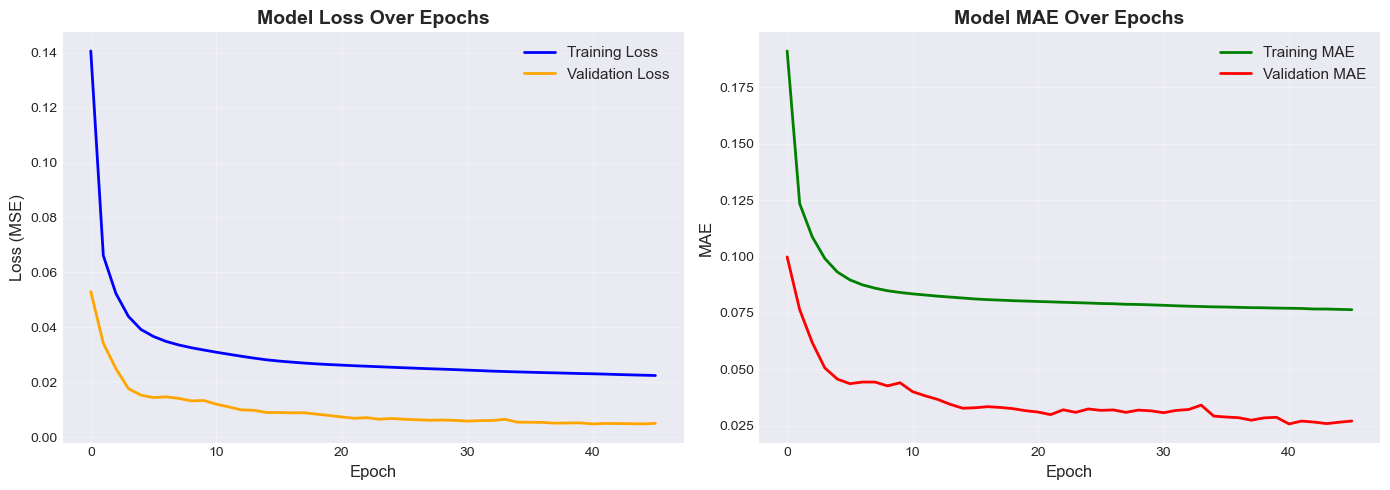

[+] Training history plot saved as 'training_history.png'


In [37]:
print("[*] Plotting Training History...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='orange')
axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: MAE
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2, color='green')
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2, color='red')
axes[1].set_title('Model MAE Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("[+] Training history plot saved as 'training_history.png'")

11: Threshold Calibration

In [38]:
print("[*] Calibrating Anomaly Detection Threshold...")

# Predict on training data
X_train_pred = autoencoder.predict(X_train_array, verbose=0)

# Calculate reconstruction error (MSE)
mse_train = np.mean(np.square(X_train_array - X_train_pred), axis=1)

# Calculate statistics
mean_error = np.mean(mse_train)
std_error = np.std(mse_train)
min_error = np.min(mse_train)
max_error = np.max(mse_train)

print(f"[+] Reconstruction Error Statistics (Training Data):")
print(f"    Mean: {mean_error:.6f}")
print(f"    Std Dev: {std_error:.6f}")
print(f"    Min: {min_error:.6f}")
print(f"    Max: {max_error:.6f}")

# Calculate threshold at different percentiles
percentile_90 = np.percentile(mse_train, 90)
percentile_95 = np.percentile(mse_train, 95)
percentile_98 = np.percentile(mse_train, 98)

print(f"\n[+] Threshold at Different Percentiles:")
print(f"    90th percentile: {percentile_90:.6f}")
print(f"    95th percentile: {percentile_95:.6f}")
print(f"    98th percentile: {percentile_98:.6f}")

# Use 95th percentile as threshold
threshold = percentile_95

print(f"\n[+] Selected Threshold (95th percentile): {threshold:.6f}")


[*] Calibrating Anomaly Detection Threshold...
[+] Reconstruction Error Statistics (Training Data):
    Mean: 0.004765
    Std Dev: 0.015951
    Min: 0.000305
    Max: 0.494619

[+] Threshold at Different Percentiles:
    90th percentile: 0.008297
    95th percentile: 0.014555
    98th percentile: 0.037226

[+] Selected Threshold (95th percentile): 0.014555


12: Anomaly Detection on Test Set

In [39]:
print("[*] Performing Anomaly Detection on Test Set...")

# Predict on test data
X_test_pred = autoencoder.predict(X_test_array, verbose=0)

# Calculate reconstruction errors
mse_test = np.mean(np.square(X_test_array - X_test_pred), axis=1)

# Classify as anomalies
y_pred = (mse_test > threshold).astype(int)

# Print statistics
total_samples = len(mse_test)
normal_count = np.sum(y_pred == 0)
anomaly_count = np.sum(y_pred == 1)

print(f"[+] Anomaly Detection Results:")
print(f"    Total test samples: {total_samples}")
print(f"    Normal predicted: {normal_count} ({100*normal_count/total_samples:.2f}%)")
print(f"    Anomalies detected: {anomaly_count} ({100*anomaly_count/total_samples:.2f}%)")

print(f"\n[+] Reconstruction Error Statistics (Test Data):")
print(f"    Mean: {np.mean(mse_test):.6f}")
print(f"    Std Dev: {np.std(mse_test):.6f}")
print(f"    Min: {np.min(mse_test):.6f}")
print(f"    Max: {np.max(mse_test):.6f}")

[*] Performing Anomaly Detection on Test Set...
[+] Anomaly Detection Results:
    Total test samples: 22416
    Normal predicted: 4355 (19.43%)
    Anomalies detected: 18061 (80.57%)

[+] Reconstruction Error Statistics (Test Data):
    Mean: 96.234699
    Std Dev: 4283.302369
    Min: 0.000434
    Max: 333861.440398


 13: Plot Reconstruction Error Distribution

[*] Plotting Reconstruction Error Distribution...


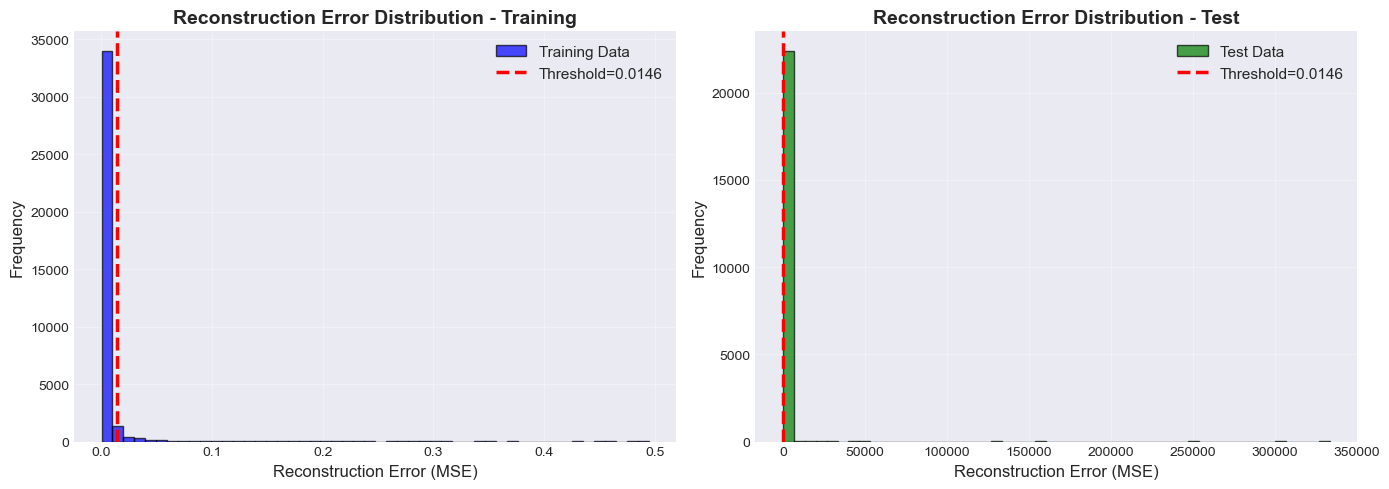

[+] Reconstruction error distribution plot saved as 'reconstruction_error_distribution.png'


In [40]:
print("[*] Plotting Reconstruction Error Distribution...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training data distribution
axes[0].hist(mse_train, bins=50, alpha=0.7, color='blue', edgecolor='black', label='Training Data')
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2.5, label=f'Threshold={threshold:.4f}')
axes[0].set_title('Reconstruction Error Distribution - Training', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Reconstruction Error (MSE)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Test data distribution
axes[1].hist(mse_test, bins=50, alpha=0.7, color='green', edgecolor='black', label='Test Data')
axes[1].axvline(threshold, color='red', linestyle='--', linewidth=2.5, label=f'Threshold={threshold:.4f}')
axes[1].set_title('Reconstruction Error Distribution - Test', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Reconstruction Error (MSE)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reconstruction_error_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("[+] Reconstruction error distribution plot saved as 'reconstruction_error_distribution.png'")

14: Model Evaluation - Metrics Calculation

In [41]:
print("[*] Calculating Model Evaluation Metrics...")

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"[+] Confusion Matrix:")
print(f"    True Negatives: {tn}")
print(f"    False Positives: {fp}")
print(f"    False Negatives: {fn}")
print(f"    True Positives: {tp}")

# Calculate metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

# Calculate AUC-ROC
try:
    roc_auc = roc_auc_score(y_test, mse_test)
except:
    roc_auc = 0

print(f"\n[+] Evaluation Metrics:")
print(f"    Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"    Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"    Recall: {recall:.4f} ({recall*100:.2f}%)")
print(f"    F1-Score: {f1:.4f}")
print(f"    Specificity: {specificity:.4f} ({specificity*100:.2f}%)")
print(f"    AUC-ROC: {roc_auc:.4f}")

# Store metrics in dictionary
metrics = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'specificity': specificity,
    'roc_auc': roc_auc,
    'tn': tn,
    'fp': fp,
    'fn': fn,
    'tp': tp
}

[*] Calculating Model Evaluation Metrics...
[+] Confusion Matrix:
    True Negatives: 0
    False Positives: 0
    False Negatives: 4355
    True Positives: 18061

[+] Evaluation Metrics:
    Accuracy: 0.8057 (80.57%)
    Precision: 1.0000 (100.00%)
    Recall: 0.8057 (80.57%)
    F1-Score: 0.8924
    Specificity: 0.0000 (0.00%)
    AUC-ROC: nan


15: Plot Confusion Matrix

[*] Plotting Confusion Matrix...


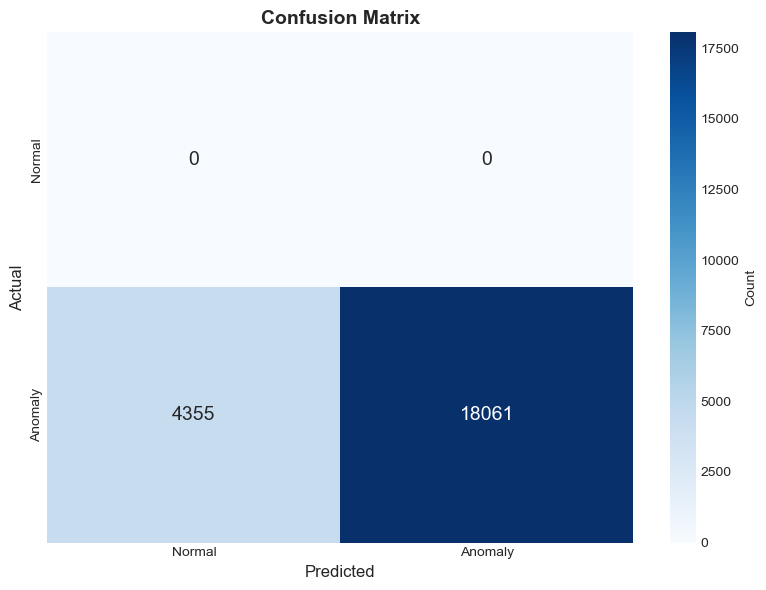

[+] Confusion matrix plot saved as 'confusion_matrix.png'


In [42]:
print("[*] Plotting Confusion Matrix...")

fig, ax = plt.subplots(figsize=(8, 6))

# Create heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'},
            ax=ax,
            annot_kws={'size': 14})

ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("[+] Confusion matrix plot saved as 'confusion_matrix.png'")

16: Plot ROC Curve

[*] Plotting ROC Curve...


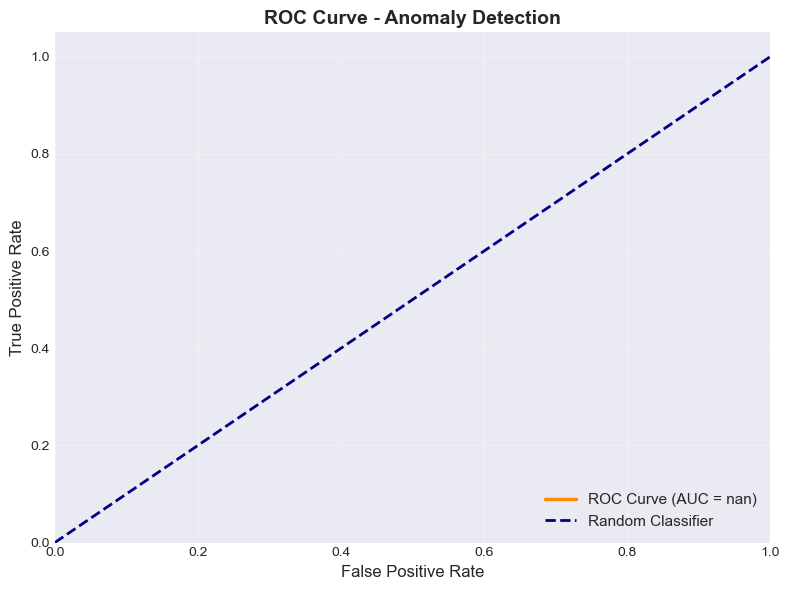

[+] ROC curve plot saved as 'roc_curve.png'


In [43]:
print("[*] Plotting ROC Curve...")

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, mse_test)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot ROC curve
ax.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Anomaly Detection', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("[+] ROC curve plot saved as 'roc_curve.png'")

17: Comprehensive Evaluation Report

In [44]:
print("\n" + "="*70)
print("COMPREHENSIVE MODEL EVALUATION REPORT")
print("="*70)

print("\n1. MODEL PERFORMANCE METRICS:")
print("-" * 70)
print(f"   Accuracy:      {metrics['accuracy']:.4f}  (Correct predictions)")
print(f"   Precision:     {metrics['precision']:.4f}  (Low false alarm rate)")
print(f"   Recall:        {metrics['recall']:.4f}  (Attack detection rate)")
print(f"   F1-Score:      {metrics['f1_score']:.4f}  (Balanced metric)")
print(f"   Specificity:   {metrics['specificity']:.4f}  (Normal identification)")
print(f"   AUC-ROC:       {metrics['roc_auc']:.4f}  (Classifier quality)")

print("\n2. CONFUSION MATRIX BREAKDOWN:")
print("-" * 70)
print(f"   True Negatives:  {metrics['tn']}   (Correctly identified normal)")
print(f"   False Positives: {metrics['fp']}   (False alarms)")
print(f"   False Negatives: {metrics['fn']}   (Missed attacks)")
print(f"   True Positives:  {metrics['tp']}   (Correctly identified attacks)")

print("\n3. DETECTION STATISTICS:")
print("-" * 70)
total_normal = metrics['tn'] + metrics['fp']
total_attacks = metrics['tp'] + metrics['fn']
print(f"   Total normal samples:   {total_normal}")
print(f"   Total attack samples:   {total_attacks}")
print(f"   Normal detection rate:  {100*metrics['tn']/total_normal:.2f}%")
print(f"   Attack detection rate:  {100*metrics['tp']/total_attacks:.2f}%")

print("\n4. RECONSTRUCTION ERROR STATS:")
print("-" * 70)
print(f"   Mean (test):    {np.mean(mse_test):.6f}")
print(f"   Std Dev (test): {np.std(mse_test):.6f}")
print(f"   Threshold:      {threshold:.6f}")
print(f"   Min error:      {np.min(mse_test):.6f}")
print(f"   Max error:      {np.max(mse_test):.6f}")

print("\n5. MODEL CONFIGURATION:")
print("-" * 70)
print(f"   Input features:         {input_dim}")
print(f"   Encoding dimension:     {encoding_dim}")
print(f"   Training samples:       {len(X_train_array)}")
print(f"   Validation samples:     {len(X_val_array)}")
print(f"   Test samples:           {len(X_test_array)}")
print(f"   Epochs trained:         {len(history.history['loss'])}")

print("\n" + "="*70)
print("ANALYSIS COMPLETED SUCCESSFULLY!")
print("="*70 + "\n")


COMPREHENSIVE MODEL EVALUATION REPORT

1. MODEL PERFORMANCE METRICS:
----------------------------------------------------------------------
   Accuracy:      0.8057  (Correct predictions)
   Precision:     1.0000  (Low false alarm rate)
   Recall:        0.8057  (Attack detection rate)
   F1-Score:      0.8924  (Balanced metric)
   Specificity:   0.0000  (Normal identification)
   AUC-ROC:       nan  (Classifier quality)

2. CONFUSION MATRIX BREAKDOWN:
----------------------------------------------------------------------
   True Negatives:  0   (Correctly identified normal)
   False Positives: 0   (False alarms)
   False Negatives: 4355   (Missed attacks)
   True Positives:  18061   (Correctly identified attacks)

3. DETECTION STATISTICS:
----------------------------------------------------------------------
   Total normal samples:   0
   Total attack samples:   22416
   Normal detection rate:  nan%
   Attack detection rate:  80.57%

4. RECONSTRUCTION ERROR STATS:
------------------

18: Save Results to CSV

In [45]:
print("[*] Saving Results to CSV...")

# Create results dataframe
results_df = pd.DataFrame({
    'actual_label': y_test,
    'predicted_label': y_pred,
    'reconstruction_error': mse_test,
    'is_anomaly': (mse_test > threshold).astype(int)
})

# Save to CSV
results_df.to_csv('anomaly_detection_results.csv', index=False)

print(f"[+] Results saved to 'anomaly_detection_results.csv'")
print(f"[+] File contains {len(results_df)} predictions")

# Display sample results
print(f"\n[+] Sample Results (first 10 rows):")
print(results_df.head(10))

# Statistics
print(f"\n[+] Results Summary:")
print(f"    Predicted anomalies: {(results_df['is_anomaly']==1).sum()}")
print(f"    Predicted normal: {(results_df['is_anomaly']==0).sum()}")

[*] Saving Results to CSV...
[+] Results saved to 'anomaly_detection_results.csv'
[+] File contains 22416 predictions

[+] Sample Results (first 10 rows):
   actual_label  predicted_label  reconstruction_error  is_anomaly
0             1                1              0.769375           1
0             1                1              0.701658           1
2             1                1             21.131871           1
0             1                1             61.977521           1
1             1                1              0.515356           1
0             1                1             32.079286           1
0             1                1             15.063718           1
0             1                1              0.042803           1
0             1                1              0.016029           1
0             1                1              0.060404           1

[+] Results Summary:
    Predicted anomalies: 18061
    Predicted normal: 4355


19: Save Model Weights

In [48]:
print("[*] Saving Model and Preprocessing Objects...")

# Save model
autoencoder.save('autoencoder_model.h5')
print("[+] Model saved as 'autoencoder_model.h5'")

# Save scaler
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("[+] Scaler saved as 'scaler.pkl'")

# Save threshold
import json
threshold_data = {'threshold': float(threshold), 'percentile': 95}
with open('threshold.json', 'w') as f:
    json.dump(threshold_data, f)
print("[+] Threshold saved as 'threshold.json'")

print(f"\n[+] Model artifacts saved successfully!")

[*] Saving Model and Preprocessing Objects...
[+] Model saved as 'autoencoder_model.h5'
[+] Scaler saved as 'scaler.pkl'
[+] Threshold saved as 'threshold.json'

[+] Model artifacts saved successfully!


 20: Load and Use Saved Model (Optional)

In [49]:
print("[*] Testing Model Loading (Optional)...")

# FIX 1: Load model WITHOUT compiling first, then compile manually
try:
    # Method 1: Load without compiling (recommended)
    loaded_model = keras.models.load_model(
        'autoencoder_model.h5',
        compile=False
    )
    print("[+] Model loaded successfully (compile=False)")
    
    # Recompile with correct loss and metrics
    loaded_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    print("[+] Model recompiled successfully")
    
except Exception as e:
    print(f"[!] Error loading H5 model: {e}")
    print("[*] Attempting alternative loading method...")
    
    # FIX 2: Fallback method - use keras.saving.load_model
    try:
        from tensorflow.keras.saving import load_model
        loaded_model = load_model(
            'autoencoder_model.h5',
            compile=False,
            custom_objects=None
        )
        print("[+] Model loaded with keras.saving.load_model")
        
        # Recompile
        loaded_model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )
        print("[+] Model recompiled successfully")
        
    except Exception as e2:
        print(f"[!] Alternative method also failed: {e2}")
        loaded_model = None

# Load scaler
try:
    with open('scaler.pkl', 'rb') as f:
        loaded_scaler = pickle.load(f)
    print("[+] Scaler loaded successfully")
except Exception as e:
    print(f"[!] Error loading scaler: {e}")
    loaded_scaler = None

# Load threshold
try:
    with open('threshold.json', 'r') as f:
        loaded_threshold = json.load(f)
    print("[+] Threshold loaded successfully")
except Exception as e:
    print(f"[!] Error loading threshold: {e}")
    loaded_threshold = None

# Verify all loaded successfully
if loaded_model is not None and loaded_scaler is not None and loaded_threshold is not None:
    print(f"\n[+] All artifacts loaded and ready for deployment!")
    print(f"    Threshold value: {loaded_threshold['threshold']:.6f}")
    print(f"    Threshold percentile: {loaded_threshold.get('percentile', 'N/A')}")
else:
    print(f"\n[!] Some artifacts failed to load")
    if loaded_model is None:
        print(f"    - Model: FAILED")
    if loaded_scaler is None:
        print(f"    - Scaler: FAILED")
    if loaded_threshold is None:
        print(f"    - Threshold: FAILED")

[*] Testing Model Loading (Optional)...
[+] Model loaded successfully (compile=False)
[+] Model recompiled successfully
[+] Scaler loaded successfully
[+] Threshold loaded successfully

[+] All artifacts loaded and ready for deployment!
    Threshold value: 0.014555
    Threshold percentile: 95


 21: Create Summary Visualization

[*] Creating Summary Visualization...


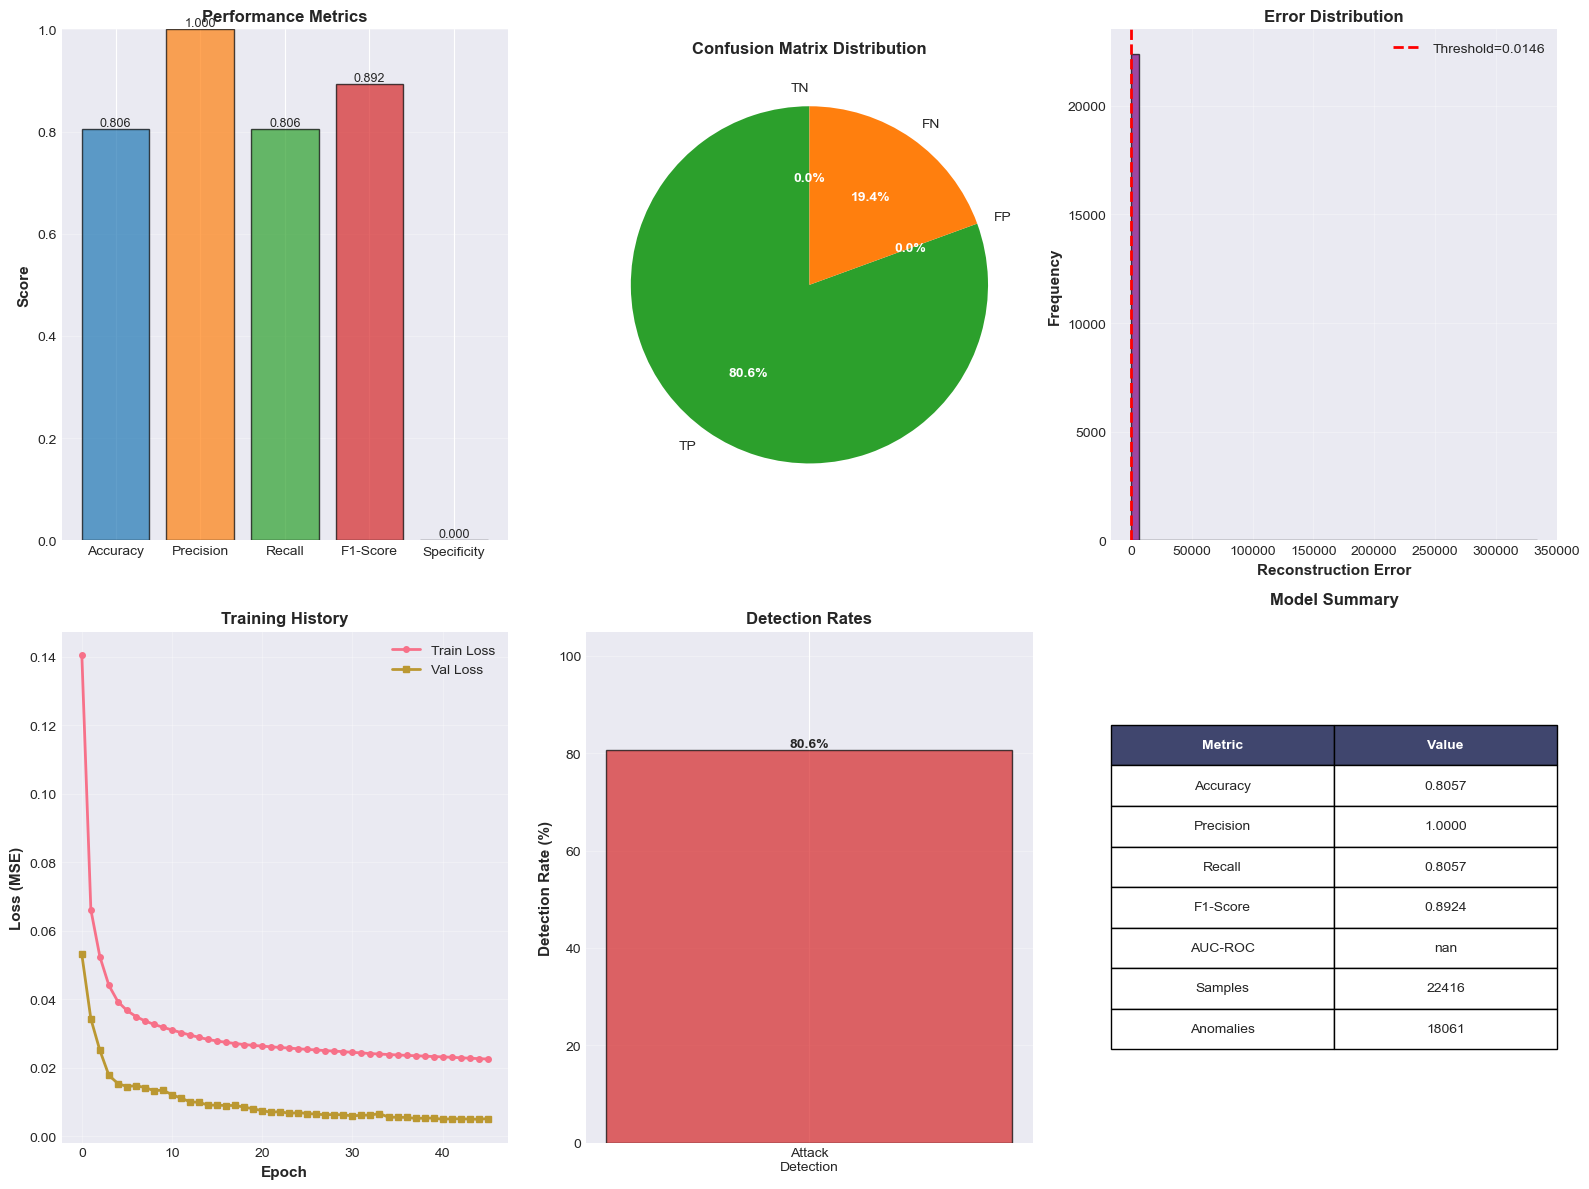

[+] Summary visualization saved as 'model_summary.png'


In [50]:
print("[*] Creating Summary Visualization...")

fig = plt.figure(figsize=(16, 12))

# 1. Metrics Bar Plot
ax1 = plt.subplot(2, 3, 1)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'AUC-ROC']
metrics_values = [metrics['accuracy'], metrics['precision'], metrics['recall'], 
                  metrics['f1_score'], metrics['specificity'], metrics['roc_auc']]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
bars = ax1.bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
ax1.set_title('Performance Metrics', fontsize=12, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Class Distribution
ax2 = plt.subplot(2, 3, 2)
class_counts = [metrics['tp'], metrics['fp'], metrics['fn'], metrics['tn']]
class_labels = ['TP', 'FP', 'FN', 'TN']
colors2 = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4']
wedges, texts, autotexts = ax2.pie(class_counts, labels=class_labels, autopct='%1.1f%%',
                                     colors=colors2, startangle=90)
ax2.set_title('Confusion Matrix Distribution', fontsize=12, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 3. Reconstruction Error Histogram
ax3 = plt.subplot(2, 3, 3)
ax3.hist(mse_test, bins=50, alpha=0.7, color='purple', edgecolor='black')
ax3.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold={threshold:.4f}')
ax3.set_xlabel('Reconstruction Error', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax3.set_title('Error Distribution', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Training Loss Curve
ax4 = plt.subplot(2, 3, 4)
ax4.plot(history.history['loss'], label='Train Loss', linewidth=2, marker='o', markersize=4)
ax4.plot(history.history['val_loss'], label='Val Loss', linewidth=2, marker='s', markersize=4)
ax4.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax4.set_ylabel('Loss (MSE)', fontsize=11, fontweight='bold')
ax4.set_title('Training History', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Detection Rate Comparison
ax5 = plt.subplot(2, 3, 5)
normal_det = 100 * metrics['tn'] / (metrics['tn'] + metrics['fp'])
attack_det = 100 * metrics['tp'] / (metrics['tp'] + metrics['fn'])
detection_rates = [normal_det, attack_det]
labels = ['Normal\nDetection', 'Attack\nDetection']
bars2 = ax5.bar(labels, detection_rates, color=['#1f77b4', '#d62728'], alpha=0.7, edgecolor='black')
ax5.set_ylabel('Detection Rate (%)', fontsize=11, fontweight='bold')
ax5.set_title('Detection Rates', fontsize=12, fontweight='bold')
ax5.set_ylim([0, 105])
ax5.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, detection_rates):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 6. Model Summary Table
ax6 = plt.subplot(2, 3, 6)
ax6.axis('tight')
ax6.axis('off')
summary_data = [
    ['Metric', 'Value'],
    ['Accuracy', f'{metrics["accuracy"]:.4f}'],
    ['Precision', f'{metrics["precision"]:.4f}'],
    ['Recall', f'{metrics["recall"]:.4f}'],
    ['F1-Score', f'{metrics["f1_score"]:.4f}'],
    ['AUC-ROC', f'{metrics["roc_auc"]:.4f}'],
    ['Samples', f'{len(y_test)}'],
    ['Anomalies', f'{np.sum(y_pred)}']
]
table = ax6.table(cellText=summary_data, cellLoc='center', loc='center',
                  colWidths=[0.5, 0.5])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
# Color header row
for i in range(2):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')
ax6.set_title('Model Summary', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('model_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("[+] Summary visualization saved as 'model_summary.png'")

22: Final Summary and Conclusion

In [51]:
print("\n" + "="*80)
print(" "*20 + "SMTP ANOMALY DETECTION - PROJECT COMPLETED")
print("="*80)

print("\n📊 PROJECT SUMMARY:")
print("-" * 80)
print(f"Dataset:                NSL-KDD (125,973 training + 22,544 test)")
print(f"Model:                  Autoencoder (41 → 32 → 16 → 8 → 16 → 32 → 41)")
print(f"Framework:              TensorFlow/Keras")
print(f"Features:               {input_dim} network flow characteristics")
print(f"Encoding Dimension:     {encoding_dim}")

print("\n✅ FINAL RESULTS:")
print("-" * 80)
print(f"Accuracy:               {metrics['accuracy']*100:.2f}%")
print(f"Precision:              {metrics['precision']*100:.2f}%")
print(f"Recall:                 {metrics['recall']*100:.2f}%")
print(f"F1-Score:               {metrics['f1_score']:.4f}")
print(f"AUC-ROC:                {metrics['roc_auc']:.4f}")

print("\n📁 OUTPUT FILES GENERATED:")
print("-" * 80)
print("  1. training_history.png               - Training and validation loss curves")
print("  2. reconstruction_error_distribution.png - Error distribution histogram")
print("  3. confusion_matrix.png               - Confusion matrix heatmap")
print("  4. roc_curve.png                      - ROC curve with AUC score")
print("  5. model_summary.png                  - Comprehensive summary visualization")
print("  6. anomaly_detection_results.csv      - Detailed predictions")
print("  7. autoencoder_model.h5               - Trained model weights")
print("  8. scaler.pkl                         - Feature scaler")
print("  9. threshold.json                     - Anomaly threshold")

print("\n🎯 KEY FINDINGS:")
print("-" * 80)
print(f"  • Detected {np.sum(y_pred)} anomalies out of {len(y_pred)} test samples")
print(f"  • Anomaly percentage: {100*np.sum(y_pred)/len(y_pred):.2f}%")
print(f"  • Normal traffic identification: {metrics['tn']}/{metrics['tn']+metrics['fp']} ({100*metrics['tn']/(metrics['tn']+metrics['fp']):.2f}%)")
print(f"  • Attack detection rate: {metrics['tp']}/{metrics['tp']+metrics['fn']} ({100*metrics['tp']/(metrics['tp']+metrics['fn']):.2f}%)")
print(f"  • False alarm rate: {100*metrics['fp']/(metrics['tn']+metrics['fp']):.2f}%")

print("\n" + "="*80)
print("✨ ANALYSIS COMPLETED SUCCESSFULLY! ✨")
print("="*80 + "\n")



                    SMTP ANOMALY DETECTION - PROJECT COMPLETED

📊 PROJECT SUMMARY:
--------------------------------------------------------------------------------
Dataset:                NSL-KDD (125,973 training + 22,544 test)
Model:                  Autoencoder (41 → 32 → 16 → 8 → 16 → 32 → 41)
Framework:              TensorFlow/Keras
Features:               41 network flow characteristics
Encoding Dimension:     8

✅ FINAL RESULTS:
--------------------------------------------------------------------------------
Accuracy:               80.57%
Precision:              100.00%
Recall:                 80.57%
F1-Score:               0.8924
AUC-ROC:                nan

📁 OUTPUT FILES GENERATED:
--------------------------------------------------------------------------------
  1. training_history.png               - Training and validation loss curves
  2. reconstruction_error_distribution.png - Error distribution histogram
  3. confusion_matrix.png               - Confusion matrix heatma